##**[3주차]과제**
- 아래의 과제1)의 코드를 완성하시오.
- 모든 코드의 결과를 출력하여, .ipynb의 링크를 **[3주차]/[3주차]과제**에 제출하시오.\
(실습 제출 예시: 3주차_2020XXXX_이름.ipynb 코드 링크)

In [ ]:
print("2353881, 최대영")

In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

###**과제1) MLP 구현**  

- 아래 그림이 나타내는 구조의 신경망을 구현해보자.  
1. Model parameter shape 고려
2. Model 초기값 고려(W1, W2의 초기값은 그림에 표기된 초기값을 사용하되 B1, B2의 초기값은 임의의 값을 사용)
- 활성화 함수는 ReLU 함수를 사용한다.

**채점 기준**  
case1 : 적절한 model weight shape (25점)  

- 그림에서 제시된대로 model의 weight shape을 맞춰야한다.  

case2 : Activation function (25점)  

- Activation Function이 ReLU 함수를 사용했는지 테스트한다.  

case3 : 학습 결과 (50점)
- 학습된 모델이 XOR 문제를 해결할 수 있는지 확인한다.

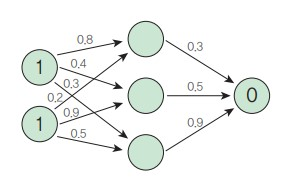

In [ ]:
import numpy as np

# ReLU 함수
def actf_relu(x):
	return np.maximum(x, 0)

# ReLU 함수의 미분치
def relu_actf_deriv(x):
    return  np.where(x > 0, 1, 0)

# 입력유닛의 개수, 은닉유닛의 개수, 출력유닛의 개수
inputs, hiddens, outputs = 2, 3, 1
learning_rate=0.05

# 훈련 샘플과 정답
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
T = np.array([[1], [0], [0], [1]])

# 초기값 weight 형태를 적절히 작성한다. (초기 weight는 그림 참고)
W1 = np.array([[0.8, 0.4, 0.3],
               [0.2, 0.9, 0.5]]) # 힌트: np.shape(W1)-> (2, 3)
W2 = np.array([[0.3],
               [0.5],
               [0.9]]) # 힌트: np.shape(W2)-> (3, 1)
B1 = np.zeros(3) # 힌트: np.shape(B1)-> (3,)
B2 = np.zeros(1) # 힌트: np.shape(B2)-> (1,)

# 순방향 전파 계산
def predict(x):
        layer0 = x
        Z1 = np.dot(layer0, W1)+B1
        layer1 = actf_relu(Z1)
        Z2 = np.dot(layer1, W2)+B2
        layer2 = actf_relu(Z2)
        return layer0, layer1, layer2

# 역방향 전파 계산
def fit():
    global W1, W2, B1, B2
    for i in range(500):
        for x, y in zip(X, T):
            x = np.reshape(x, (1, -1))
            y = np.reshape(y, (1, -1))

            layer0, layer1, layer2 = predict(x)
            layer2_error = layer2-y
            layer2_delta = layer2_error*relu_actf_deriv(layer2)
            layer1_error = np.dot(layer2_delta, W2.T)
            layer1_delta = layer1_error*relu_actf_deriv(layer1)

            W2 += -learning_rate*np.dot(layer1.T, layer2_delta)
            W1 += -learning_rate*np.dot(layer0.T, layer1_delta)
            B2 += -learning_rate*np.sum(layer2_delta, axis=0)
            B1 += -learning_rate*np.sum(layer1_delta, axis=0)

def test():
    for x, y in zip(X, T):
        x = np.reshape(x, (1, -1))
        layer0, layer1, layer2 = predict(x)
        print(x, y, layer2)
fit()
test()

[[0 0]] [1] [[0.]]
[[0 1]] [0] [[1.1602167e-08]]
[[1 0]] [0] [[1.43114134e-08]]
[[1 1]] [1] [[0.99999999]]
